# IdentityV Survivor Data Analysis

## Section 1 : Dataset

The Dataset I chose is about all the Survivor Data from a game called **Identity V**. ***THIS IS MY FAVORITE GAME!!*** Here is a brief introduction for better understanding the dataset:

***Identity V*** is a 1v4 asymmetrical horror mobile game developed by NetEase, where one hunter tries to capture four survivors. The core gameplay involves survivors decoding five cipher machines to escape while the hunter tries to eliminate them, often by strapping them to rocket chairs. 

**Gameplay**:

- **Survivor role**: Work with three teammates to decode a total of five cipher machines to open two exit gates and escape. You can also escape through a special dungeon that appears when only one survivor remains.
- **Hunter role**: Prevent the survivors from escaping by finding and incapacitating them. You must eliminate more than two survivors before they can escape to win.

**Key mechanics**:

- **Decoding**: Survivors can decode cipher machines, but this alerts the hunter to their general location, especially during calibrations.
- **Kiting**: Survivors can lead the hunter on a chase to buy time for their teammates to decode.
- **Rocket chairs**: If a hunter catches a survivor, they can place them in a rocket chair to be eliminated. Teammates can rescue each other, but this carries risk. 


I found this dataset from the sourse code of the **website** https://wiki.biligame.com/dwrg/%E8%A7%92%E8%89%B2%E6%95%B0%E6%8D%AE, and ask **deepseek** for help to get a csv file. Thanks a lot for both of them.

In [10]:
import pandas as pd
df = pd.read_csv("IdentityV_Survivor_Data.csv")
df

,Character,Model Radius,Rescue Time from Chair,Running Speed,Walking Speed,Crouching Speed,Crawling Speed,Decoding Time,Calibration Fail Regression,Calibration Fail Lockout,...,Fast Window Vault,Slow Window Vault,Chest Opening Time,Healing Others,Healing Time when Injured,Self Heal when Downed,Footprint Duration,Hit Speed Boost Duration,Struggle Free Time,Rocket Chair Ascent Time
0,Batter,0.34,1,3.80,2.11,1.14,0.44,101.25,1,2.0,...,0.73,1.06,10,15.00,15.00,30.00,4,2,16.00,60.00
1,Forward,0.34,1,3.80,2.11,1.14,0.44,108.00,1,2.0,...,0.73,1.06,10,15.00,15.00,30.00,4,2,14.55,60.00
2,Mercenary,0.34,1,3.80,2.11,1.14,0.44,108.00,1,2.0,...,0.79,1.15,10,15.00,17.25,39.00,4,2,16.00,66.67
3,Coordinator,0.34,1,3.80,2.11,1.14,0.44,108.00,1,2.0,...,0.79,1.15,10,15.00,15.00,30.00,4,2,16.00,66.67
4,Acrobat,0.34,1,3.80,2.11,1.14,0.44,95.29,1,2.0,...,0.79,1.15,10,15.00,15.00,30.00,4,2,16.00,60.00
5,Lucky Guy,0.34,1,3.80,2.11,1.14,0.44,81.00,1,2.0,...,0.87,1.27,5,15.00,15.00,30.00,4,4,16.00,60.00
6,Thief,0.34,1,3.80,2.11,1.14,0.44,81.00,1,2.0,...,0.87,0.87,5,15.00,15.00,30.00,4,2,16.00,60.00
7,Magician,0.34,1,3.80,2.11,1.14,0.44,81.00,1,2.0,...,0.87,1.27,10,15.00,15.00,30.00,4,2,16.00,60.00
8,Doctor,0.34,1,3.80,2.11,1.14,0.44,81.00,1,2.0,...,0.87,1.27,10,9.09,14.29,25.00,4,4,16.00,60.00
9,Gardener,0.34,1,3.80,2.11,1.14,0.44,81.00,1,2.0,...,0.87,1.27,10,15.00,15.00,30.00,4,4,16.00,66.67


In [11]:
number_Survivor = len(df) 
number_Survivor # 49 survivors in total

49

In [12]:
Survivor_list = df["Character"].tolist()
Survivor_list # survivors name list

['Batter',
 'Forward',
 'Mercenary',
 'Coordinator',
 'Acrobat',
 'Lucky Guy',
 'Thief',
 'Magician',
 'Doctor',
 'Gardener',
 'Lawyer',
 'Explorer',
 'Priestess',
 'Mechanic',
 "Mind's Eye",
 'Cowboy',
 'First Officer',
 'Perfumer',
 'Female Dancer',
 'Seer',
 'Embalmer',
 'Enchantress',
 'Wildling',
 'Prospector',
 'Postman',
 'Prisoner',
 'Entomologist',
 'Painter',
 'Grave Keeper',
 'Psychologist',
 'Patient',
 'Weeping Clown',
 'Barmaid',
 'Little Girl',
 'Novelist',
 'Professor',
 'Cheerleader',
 'Toy Merchant',
 'Composer',
 'Journalist',
 'Aviator',
 'Knight',
 'Archaeologist',
 'Meteorologist',
 'Puppeteer',
 'Fire Investigator',
 'Lady Farrow',
 'Projectionist',
 'Archer']

In [13]:
columns_list = df.columns.tolist()
columns_list # in which lens the survivors be evaluated

['Character',
 'Model Radius',
 'Rescue Time from Chair',
 'Running Speed',
 'Walking Speed',
 'Crouching Speed',
 'Crawling Speed',
 'Decoding Time',
 'Calibration Fail Regression',
 'Calibration Fail Lockout',
 'Door Opening Time',
 'Pallet Pull Down Time',
 'Fast Pallet Vault',
 'Medium Pallet Vault',
 'Slow Pallet Vault',
 'Fast Window Vault',
 'Slow Window Vault',
 'Chest Opening Time',
 'Healing Others',
 'Healing Time when Injured',
 'Self Heal when Downed',
 'Footprint Duration',
 'Hit Speed Boost Duration',
 'Struggle Free Time',
 'Rocket Chair Ascent Time']

As we can see in the above code. This DataFrame contains the data of 48 different survivors, and evaluating the personalities of the survivors in 24 different ways.

## Section2 : Exploratory Data Analysis

**Rescue role** is the key position of 4 survivors' team. Because successful rescues are essential for buying time for teammates to decode cipher machines, preventing early elimination of survivors, and ultimately achieving the win condition of having three or more survivors escape. 

The key personality for a rescue role is that its **Rocket Chair Ascent Time** will be longer than others.

In [14]:
df_rescue_role = df[df["Rocket Chair Ascent Time"] > 60]
df_others = df[df["Rocket Chair Ascent Time"] <= 60]
df_rescue_role

,Character,Model Radius,Rescue Time from Chair,Running Speed,Walking Speed,Crouching Speed,Crawling Speed,Decoding Time,Calibration Fail Regression,Calibration Fail Lockout,...,Fast Window Vault,Slow Window Vault,Chest Opening Time,Healing Others,Healing Time when Injured,Self Heal when Downed,Footprint Duration,Hit Speed Boost Duration,Struggle Free Time,Rocket Chair Ascent Time
2,Mercenary,0.34,1,3.8,2.11,1.14,0.44,108.00,1,2.0,...,0.79,1.15,10,15.0,17.25,39.0,4,2,16.0,66.67
3,Coordinator,0.34,1,3.8,2.11,1.14,0.44,108.00,1,2.0,...,0.79,1.15,10,15.0,15.00,30.0,4,2,16.0,66.67
9,Gardener,0.34,1,3.8,2.11,1.14,0.44,81.00,1,2.0,...,0.87,1.27,10,15.0,15.00,30.0,4,4,16.0,66.67
16,First Officer,0.34,1,3.8,2.11,1.14,0.44,101.25,1,2.0,...,0.87,1.27,10,15.0,15.00,30.0,4,2,16.0,75.00
20,Embalmer,0.34,1,3.8,2.11,1.14,0.44,81.00,1,2.0,...,0.87,1.27,10,15.0,15.00,30.0,4,2,16.0,66.67
39,Journalist,0.34,1,3.8,2.11,1.14,0.44,90.00,1,2.0,...,0.87,1.27,10,15.0,15.00,30.0,4,2,16.0,66.67


**Decoding** ability is a very important evaluation point for survivors. Survivors must decode five cipher machines to escape.

In [15]:
mean_decoding_time = df["Decoding Time"].mean()
mean_decoding_time

np.float64(85.04102040816326)

Because the average decoding time is 85 seconds, I will categrize all the other survivors (except rescue role) into fast decoders, normal decoders, and slow decoders by 75 seconds, 85 seconds, and 95 seconds.

In [16]:
fast_decoders = df_others[df_others["Decoding Time"] < 75]
fast_decoders

,Character,Model Radius,Rescue Time from Chair,Running Speed,Walking Speed,Crouching Speed,Crawling Speed,Decoding Time,Calibration Fail Regression,Calibration Fail Lockout,...,Fast Window Vault,Slow Window Vault,Chest Opening Time,Healing Others,Healing Time when Injured,Self Heal when Downed,Footprint Duration,Hit Speed Boost Duration,Struggle Free Time,Rocket Chair Ascent Time
10,Lawyer,0.34,1,3.8,2.11,1.14,0.44,70.43,1,2.0,...,0.87,1.27,10,15.0,15.0,30.0,4,4,16.0,60.0
13,Mechanic,0.34,1,3.8,2.11,1.14,0.44,73.64,1,2.0,...,1.02,1.49,10,15.0,15.0,30.0,4,2,16.0,60.0
14,Mind's Eye,0.34,1,3.8,2.64,1.14,0.44,65.85,1,2.0,...,1.02,1.49,10,15.0,15.0,30.0,4,2,16.0,60.0
25,Prisoner,0.34,1,3.8,2.11,1.14,0.44,73.64,1,1.4,...,0.87,1.27,10,15.0,15.0,30.0,4,2,16.0,60.0
38,Composer,0.34,1,3.8,2.11,1.14,0.44,67.50,0,0.0,...,0.87,1.27,10,15.0,15.0,30.0,4,2,16.0,60.0
46,Lady Farrow,0.34,1,3.8,2.11,1.14,0.44,72.90,1,2.0,...,0.87,1.27,10,15.0,15.0,30.0,4,2,16.0,60.0


In [17]:
norm_decoders = df_others[(df_others["Decoding Time"] >= 75) & (df_others["Decoding Time"] <= 95)]
norm_decoders

,Character,Model Radius,Rescue Time from Chair,Running Speed,Walking Speed,Crouching Speed,Crawling Speed,Decoding Time,Calibration Fail Regression,Calibration Fail Lockout,...,Fast Window Vault,Slow Window Vault,Chest Opening Time,Healing Others,Healing Time when Injured,Self Heal when Downed,Footprint Duration,Hit Speed Boost Duration,Struggle Free Time,Rocket Chair Ascent Time
5,Lucky Guy,0.34,1,3.8,2.11,1.14,0.44,81.00,1,2.0,...,0.87,1.27,5,15.00,15.00,30.00,4,4,16.0,60.0
6,Thief,0.34,1,3.8,2.11,1.14,0.44,81.00,1,2.0,...,0.87,0.87,5,15.00,15.00,30.00,4,2,16.0,60.0
7,Magician,0.34,1,3.8,2.11,1.14,0.44,81.00,1,2.0,...,0.87,1.27,10,15.00,15.00,30.00,4,2,16.0,60.0
8,Doctor,0.34,1,3.8,2.11,1.14,0.44,81.00,1,2.0,...,0.87,1.27,10,9.09,14.29,25.00,4,4,16.0,60.0
11,Explorer,0.34,1,3.8,2.11,1.14,0.44,81.00,1,2.0,...,0.87,1.27,10,15.00,15.00,30.00,3,2,16.0,60.0
12,Priestess,0.34,1,3.8,2.11,1.14,0.44,90.00,1,2.0,...,0.97,1.41,10,13.50,10.50,21.00,4,2,16.0,60.0
15,Cowboy,0.34,1,3.8,2.11,1.14,0.44,90.00,1,2.0,...,0.87,1.27,10,15.00,15.00,30.00,4,2,16.0,60.0
17,Perfumer,0.34,1,3.8,2.11,1.14,0.44,81.00,3,2.0,...,0.87,1.27,10,15.00,17.25,34.50,4,2,16.0,60.0
18,Female Dancer,0.34,1,3.8,2.11,1.14,0.44,81.00,1,2.0,...,0.87,1.27,10,15.00,15.00,30.00,4,2,16.0,60.0
19,Seer,0.34,1,3.8,2.11,1.14,0.44,81.00,1,2.0,...,0.87,1.27,10,15.00,15.00,30.00,4,2,16.0,60.0


In [18]:
slow_decoders = df_others[df_others["Decoding Time"] > 95]
slow_decoders

,Character,Model Radius,Rescue Time from Chair,Running Speed,Walking Speed,Crouching Speed,Crawling Speed,Decoding Time,Calibration Fail Regression,Calibration Fail Lockout,...,Fast Window Vault,Slow Window Vault,Chest Opening Time,Healing Others,Healing Time when Injured,Self Heal when Downed,Footprint Duration,Hit Speed Boost Duration,Struggle Free Time,Rocket Chair Ascent Time
0,Batter,0.34,1,3.80,2.11,1.14,0.44,101.25,1,2.0,...,0.73,1.06,10,15.0,15.0,30.0,4,2,16.00,60.0
1,Forward,0.34,1,3.80,2.11,1.14,0.44,108.00,1,2.0,...,0.73,1.06,10,15.0,15.0,30.0,4,2,14.55,60.0
4,Acrobat,0.34,1,3.80,2.11,1.14,0.44,95.29,1,2.0,...,0.79,1.15,10,15.0,15.0,30.0,4,2,16.00,60.0
22,Wildling,0.34,1,3.65,2.03,1.10,0.42,108.00,1,2.0,...,0.87,1.27,10,15.0,15.0,30.0,6,2,16.00,60.0
28,Grave Keeper,0.34,1,3.80,2.11,1.14,0.44,95.29,1,2.0,...,0.87,1.27,10,15.0,15.0,30.0,4,2,16.00,60.0
31,Weeping Clown,0.34,1,3.80,2.11,1.14,0.44,95.29,1,2.0,...,0.87,1.27,10,15.0,15.0,30.0,4,2,16.00,60.0
41,Knight,0.34,1,3.80,2.11,1.14,0.44,101.25,1,2.0,...,0.87,1.27,10,15.0,15.0,30.0,4,2,16.00,60.0


As a team of 4 people, usually there will be one rescue role, one fast decoder, one norm decoder, and one slow decoder. They will decode 5 machines in total. I will randomly choose from each category and simulate 1000 times to find the average time they need to decode all 5 machines.

In [19]:
import random
data = []

rescue_decodingtimelist = df_rescue_role["Decoding Time"].tolist()
fast_decodingtimelist = fast_decoders["Decoding Time"].tolist()
norm_decodingtimelist = norm_decoders["Decoding Time"].tolist()
slow_decodingtimelist = slow_decoders["Decoding Time"].tolist()

for i in range (1000):
    rescue_time = random.choice(rescue_decodingtimelist)
    fast_time = random.choice(fast_decodingtimelist)
    norm_time = random.choice(norm_decodingtimelist)
    slow_time = random.choice(slow_decodingtimelist)

    time = (rescue_time + fast_time + norm_time + slow_time) / 4 * 5

    d = {"Total Time" : time}
    data.append(d)

df_total_time = pd.DataFrame(data)
df_total_time

,Total Time
0,461.3125
1,439.7375
2,420.9000
3,431.0625
4,455.6250
...,...
995,436.6875
996,437.6750
997,446.4875
998,463.3000


In [20]:
df_total_time.min()

Total Time    403.925
dtype: float64

In [21]:
df_total_time.max()

Total Time    474.55
dtype: float64

In [22]:
df_total_time.mean()

Total Time    435.438713
dtype: float64

According to the data I get, there is a big difference from the min and max total decoding time, **more than a minute**. Longer decoding time means a greater risk of being caught by the Hunter. We should be more careful for picking the roles.

## Section3 : Exploratory Data Visualization

##### 1. The rescue role is a crucial position in a team. Let's use the bar to compare the **decoding ability of each rescue role and the average data of normal decoders**.

First, Let's add a new row called **Normal Decoder Average** by the end of the rescue role DataFrame.

In [23]:
norm_decoders_avg = pd.DataFrame({
    'Character': ['Normal Decoders Average'],
    'Decoding Time' : [norm_decoders['Decoding Time'].mean()]
})

df_rescue_role_combined = pd.concat([df_rescue_role, norm_decoders_avg], ignore_index= True)
df_rescue_role_combined

,Character,Model Radius,Rescue Time from Chair,Running Speed,Walking Speed,Crouching Speed,Crawling Speed,Decoding Time,Calibration Fail Regression,Calibration Fail Lockout,...,Fast Window Vault,Slow Window Vault,Chest Opening Time,Healing Others,Healing Time when Injured,Self Heal when Downed,Footprint Duration,Hit Speed Boost Duration,Struggle Free Time,Rocket Chair Ascent Time
0,Mercenary,0.34,1.0,3.8,2.11,1.14,0.44,108.000000,1.0,2.0,...,0.79,1.15,10.0,15.0,17.25,39.0,4.0,2.0,16.0,66.67
1,Coordinator,0.34,1.0,3.8,2.11,1.14,0.44,108.000000,1.0,2.0,...,0.79,1.15,10.0,15.0,15.00,30.0,4.0,2.0,16.0,66.67
2,Gardener,0.34,1.0,3.8,2.11,1.14,0.44,81.000000,1.0,2.0,...,0.87,1.27,10.0,15.0,15.00,30.0,4.0,4.0,16.0,66.67
3,First Officer,0.34,1.0,3.8,2.11,1.14,0.44,101.250000,1.0,2.0,...,0.87,1.27,10.0,15.0,15.00,30.0,4.0,2.0,16.0,75.00
4,Embalmer,0.34,1.0,3.8,2.11,1.14,0.44,81.000000,1.0,2.0,...,0.87,1.27,10.0,15.0,15.00,30.0,4.0,2.0,16.0,66.67
5,Journalist,0.34,1.0,3.8,2.11,1.14,0.44,90.000000,1.0,2.0,...,0.87,1.27,10.0,15.0,15.00,30.0,4.0,2.0,16.0,66.67
6,Normal Decoders Average,NaN,NaN,NaN,NaN,NaN,NaN,82.314333,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Then, use the bar visualization.

Text(0, 0.5, 'Decoding Time(Seconds)')

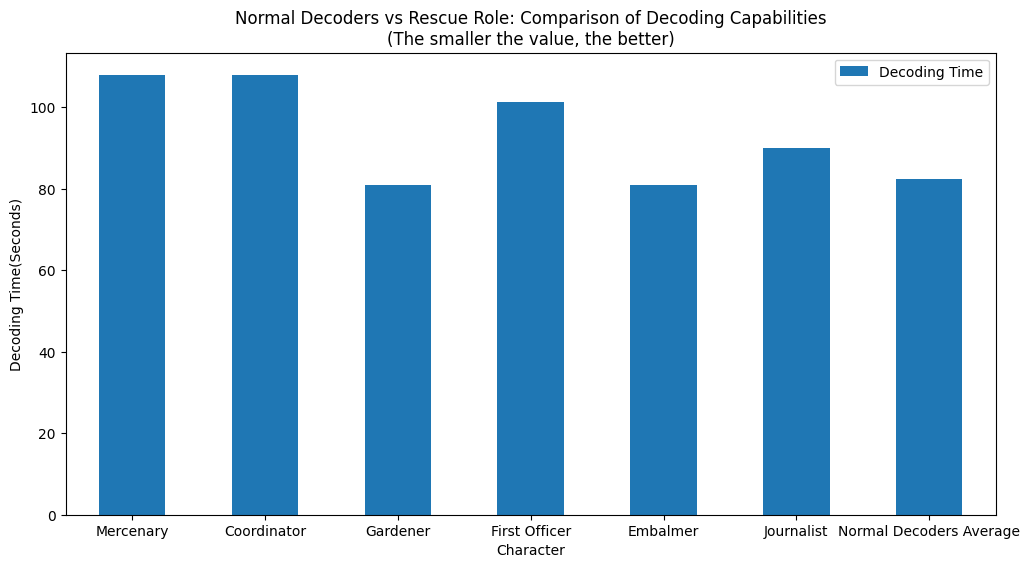

In [24]:
pic1 = df_rescue_role_combined.plot.bar("Character", "Decoding Time", figsize = (12,6), rot = 0)
pic1.set_title("Normal Decoders vs Rescue Role: Comparison of Decoding Capabilities\n(The smaller the value, the better)")
pic1.set_ylabel("Decoding Time(Seconds)")

As we can see in the pircture, except Gardner and Embalmer, whose decoding time is *slightly* shorter than Normal Decoders Average, all the other rescue roles need to take **longer** time. In conclusion, the **"Rescue Role" trait is having a decoding debuff**.

##### 2. The Relationship between survivors' Mind Gaming Capabilities and Decoding Capabilities.

"Pallet Pull Down Time, Fast Pallet Vault, Medium Pallet Vault, Slow Pallet Vault, Fast Window Vault, Slow Window Vault" are collectively known as *pallet and window interaction times*. **Shorter durations (faster speeds) represent better Mind Gaming capabilities for survivors**. And the better Mind Gaming ability a survivor has, means that it can survive longer and restrain the hunter longer, saving more time for other survivors to decode the machine. Now I'll use the scatterplot to discover the relationship between survivors' Mind Gaming Capabilities and Decoding Capabilities.

First, add some columns for different Mind Gaming Capabilities.

In [25]:
# Calculate the indicators of Mind Gaming ability (the shorter the time, the stronger the ability)
df["Pallet Mind Gaming Ability"] = 1 / df[["Pallet Pull Down Time", "Fast Pallet Vault", "Medium Pallet Vault", "Slow Pallet Vault"]].mean(axis = 1)
df["Window Mind Gaming Ability"] = 1 / df[["Fast Window Vault", "Slow Window Vault"]].mean(axis = 1)
df["Overall Mind Gaming Ability"] = (df["Pallet Mind Gaming Ability"] + df["Window Mind Gaming Ability"]) / 2
df

,Character,Model Radius,Rescue Time from Chair,Running Speed,Walking Speed,Crouching Speed,Crawling Speed,Decoding Time,Calibration Fail Regression,Calibration Fail Lockout,...,Healing Others,Healing Time when Injured,Self Heal when Downed,Footprint Duration,Hit Speed Boost Duration,Struggle Free Time,Rocket Chair Ascent Time,Pallet Mind Gaming Ability,Window Mind Gaming Ability,Overall Mind Gaming Ability
0,Batter,0.34,1,3.80,2.11,1.14,0.44,101.25,1,2.0,...,15.00,15.00,30.00,4,2,16.00,60.00,0.854701,1.117318,0.986010
1,Forward,0.34,1,3.80,2.11,1.14,0.44,108.00,1,2.0,...,15.00,15.00,30.00,4,2,14.55,60.00,0.877193,1.117318,0.997256
2,Mercenary,0.34,1,3.80,2.11,1.14,0.44,108.00,1,2.0,...,15.00,17.25,39.00,4,2,16.00,66.67,0.787402,1.030928,0.909165
3,Coordinator,0.34,1,3.80,2.11,1.14,0.44,108.00,1,2.0,...,15.00,15.00,30.00,4,2,16.00,66.67,0.787402,1.030928,0.909165
4,Acrobat,0.34,1,3.80,2.11,1.14,0.44,95.29,1,2.0,...,15.00,15.00,30.00,4,2,16.00,60.00,0.787402,1.030928,0.909165
5,Lucky Guy,0.34,1,3.80,2.11,1.14,0.44,81.00,1,2.0,...,15.00,15.00,30.00,4,4,16.00,60.00,0.714286,0.934579,0.824433
6,Thief,0.34,1,3.80,2.11,1.14,0.44,81.00,1,2.0,...,15.00,15.00,30.00,4,2,16.00,60.00,0.943396,1.149425,1.046411
7,Magician,0.34,1,3.80,2.11,1.14,0.44,81.00,1,2.0,...,15.00,15.00,30.00,4,2,16.00,60.00,0.714286,0.934579,0.824433
8,Doctor,0.34,1,3.80,2.11,1.14,0.44,81.00,1,2.0,...,9.09,14.29,25.00,4,4,16.00,60.00,0.714286,0.934579,0.824433
9,Gardener,0.34,1,3.80,2.11,1.14,0.44,81.00,1,2.0,...,15.00,15.00,30.00,4,4,16.00,66.67,0.714286,0.934579,0.824433


<Axes: xlabel='Decoding Time', ylabel='Pallet Mind Gaming Ability'>

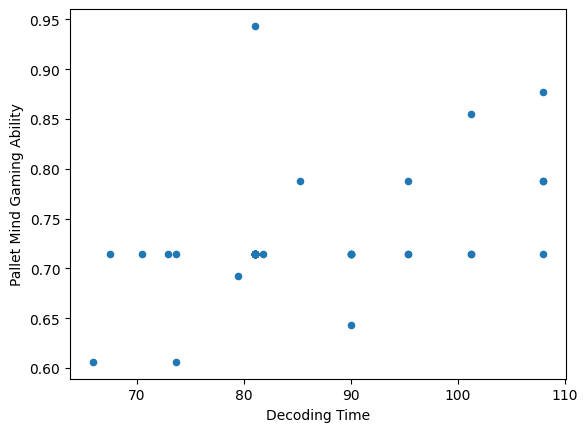

In [26]:
df.plot.scatter(x = "Decoding Time", y = "Pallet Mind Gaming Ability")

There are some survivors with the same data, but I want to show all the survivors. So I'll change it to a jitter point.

Text(0.5, 1.0, 'Decoding Time vs Pallet Mind Gaming Ability (with jitter)')

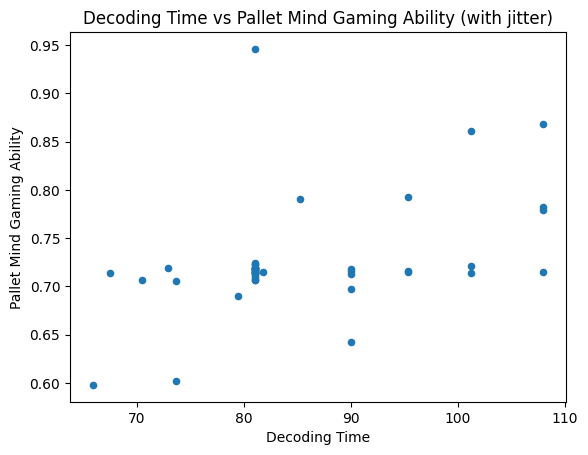

In [27]:
import numpy as np
df["Pallet Mind Gaming Ability"] = df["Pallet Mind Gaming Ability"] + np.random.normal(0,0.005,len(df))
pic2 = df.plot.scatter(x = "Decoding Time", y = "Pallet Mind Gaming Ability")
pic2.set_title("Decoding Time vs Pallet Mind Gaming Ability (with jitter)")

Then, do the same thing to "Window Mind Gaming Ability" and "Overall Mind Gaming Ability".

Text(0.5, 1.0, 'Decoding Time vs Window Mind Gaming Ability (with jitter)')

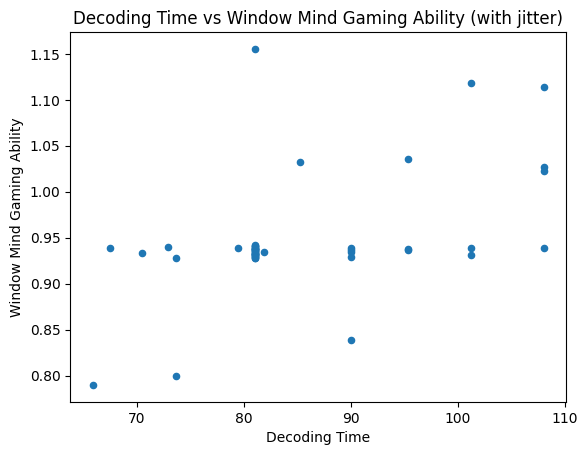

In [28]:
df["Window Mind Gaming Ability"] = df["Window Mind Gaming Ability"] + np.random.normal(0,0.005,len(df))
pic3 = df.plot.scatter(x = "Decoding Time", y = "Window Mind Gaming Ability")
pic3.set_title("Decoding Time vs Window Mind Gaming Ability (with jitter)")

Text(0.5, 1.0, 'Decoding Time vs Overall Mind Gaming Ability (with jitter)')

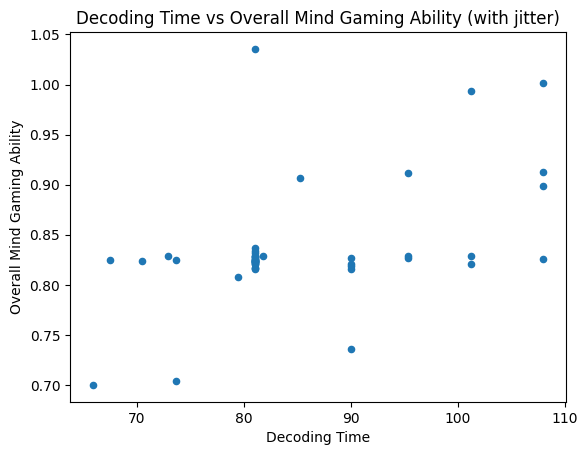

In [29]:
df["Overall Mind Gaming Ability"] = df["Overall Mind Gaming Ability"] + np.random.normal(0,0.005,len(df))
pic4 = df.plot.scatter(x = "Decoding Time", y = "Overall Mind Gaming Ability")
pic4.set_title("Decoding Time vs Overall Mind Gaming Ability (with jitter)")

Because there are fewer characters, we cannot know the **exact** relationship. **But we can roughly see that the better the Mind Gaming ability, the longer the decoding time will be**. This indicates that the game designers consciously strike a balance between the ability to decode and the Mind Gaming.

## Section 4: Planning for Part II

In the Exploratory Data Analysis about my dataset, I analyze the mean, minimmum, and maximum value of the decoding time, and use the simulation to evaluate the total decoding time with different compositions of team members. Concluding that the compositions of team members can lead to a range of more than a minute. Also, use the graph visualization to explore different survivor's capability and their relationship. For example, the "Rescue Role" trait is having a decoding debuff and the better the Mind Gaming capability, the worse the decoding capability.

In part II, I would love to explore:

1. Is there any statistical evidence suggesting that certain character types are either too powerful or too weak?
2. Based on the data, what kind of role combination is the most balanced in a team?
3. Develop regression models to better evaluate the relationship of the different capabilities I mentioned before.

## Section 5: Data Science

I will choose *Question 3*, but more spefically: **Use Linear Regression to find out which feature of the character most influence Decoding Time**

*Reason:* I believe a Linear regression model can provide a better insight. Understanding which capabilities strongly influence decoding could help the players optimize their team compositions and also give insights about the game balance.

*My plan:* I will use the linear regression to model the relationship between decoding time and other survivor capabilities. First, build a predictive model for decoding time. Second, quantify how much capability affects decoding time. Third, show the influence data in DataFrame.

In [91]:
from sklearn.linear_model import LinearRegression

feature_columns = ['Running Speed',
 'Walking Speed',
 'Crouching Speed',
 'Crawling Speed',
 'Healing Others',
 'Healing Time when Injured',
 'Self Heal when Downed',
 'Footprint Duration',
 'Hit Speed Boost Duration',
 'Struggle Free Time']


Because some of the features' data are really small(0.44) while some are really big(30), I will have these runtime warnings: 

**RuntimeWarning: divide by zero encountered in matmul**

**RuntimeWarning: overflow encountered in matmul**

**RuntimeWarning: invalid value encountered in matmul**

Therefore, I have to StandardScaler all the data, I learnt it on Google.

In [92]:
from sklearn.preprocessing import StandardScaler

X = df[feature_columns]
X = X.fillna(X.mean())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y = df["Decoding Time"]

In [93]:
model = LinearRegression()
model.fit(X_scaled, y)
y_predict = model.predict(X_scaled)

In [94]:
feature_important = pd.DataFrame({
    'feature' : feature_columns,
    'coefficient' : model.coef_
}).sort_values('coefficient', ascending= False)
feature_important

,feature,coefficient
6,Self Heal when Downed,8.567814
7,Footprint Duration,1.493705
2,Crouching Speed,-0.530834
0,Running Speed,-0.530834
3,Crawling Speed,-0.530834
8,Hit Speed Boost Duration,-1.614517
4,Healing Others,-1.963747
1,Walking Speed,-2.785261
9,Struggle Free Time,-3.214034
5,Healing Time when Injured,-7.383350


The higher the absolute value of coefficient, the bigger impact on decoding time. And the negative or positive of coeffecient suggests when this capability increases, decoding time decreases or increases.

As we can see, Healing Time when Injured has the biggest negative impact, which means that roles have better Healing Capabilities should go to rescue others rather than stay decoding, complianting with the logic of the game.

## Section 6: A Different Data Visualization

In this section, I would use the histogram to analyze two important features: ***Healing Time when Injured*** and ***Decoding Time***.

Text(0, 0.5, 'Frequency')

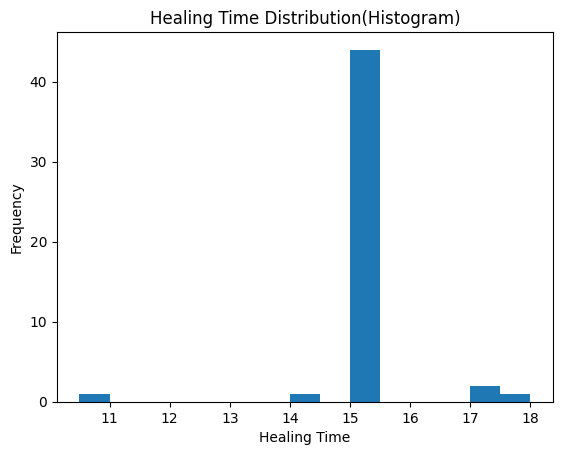

In [134]:
# Deal with the Null value in Healing Time when Injured

df_clean = df.copy()
df_clean["Healing Time when Injured"] = df_clean["Healing Time when Injured"].fillna(df_clean["Healing Time when Injured"].mean())

boxplot_Heal = df_clean["Healing Time when Injured"].plot.hist(bins = 15)
boxplot_Heal.set_title("Healing Time Distribution(Histogram)")
boxplot_Heal.set_xlabel("Healing Time")
boxplot_Heal.set_ylabel("Frequency")

Text(0, 0.5, 'Frequency')

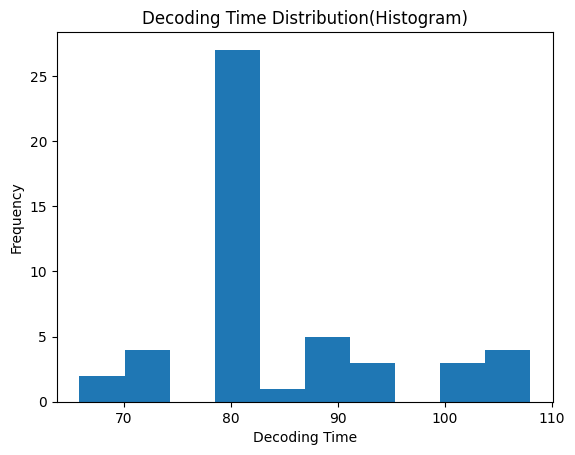

In [131]:
boxplot_Decode = df_clean["Decoding Time"].plot.hist(bins = 10)
boxplot_Decode.set_title("Decoding Time Distribution(Histogram)")
boxplot_Decode.set_xlabel("Decoding Time")
boxplot_Decode.set_ylabel("Frequency")

### Visualization Summary

These histograms reveal the distribution pattern of two key survivor capabilities. The **Healing Time histogram** shows a unimodal distribution, with a peak around 15 seconds, suggesting that most survivors have similar healing capabilities. However, the range spans from under 11 seconds to 18 seconds, representing a 7+ seconds deifference that can impact gameplay decisions. 

The **Decoding Time histogram** displays a more complex distribution with a primary peak of 80 seconds but significant varation across the spectrum. The data shows only little survivors with decoding time less than 80 seconds, suggesting that while fast decoders exist, they are minority. Also, the slow decoders are clearly more than the fast decoders. They might have other features like rescue and support which is stronger than fast decoders.

## Section 7: Overall Summary

In this project, I analyzed a CSV dataset of *49 survivors* in the game Identity V, examining various capabilities of characters such as Decoding Time, Rocket Chair Ascent Time, and healing abilities using **DataFrame**. 

I categorized the survivors into rescue roles, fast decoders, normal decoders, and slow decoders based on thresholds of 60 seconds for Rocket Chair Ascent Time and 75 seconds for Decoding Time. **Using simulation with 1000 iterations and random function in Python,** I estimated that it takes an average of 435 seconds for a randomly selected team to decode all five machines, with observed minimum and maximum times of 403.925 seconds and 474.55 seconds, respectively.

I also explored relationships between different capabilities using **visualizations**. A ***bar*** chart highlighted the average decoding time of normal decoders compared to rescue roles, while a ***scatterplot*** revealed the correlation between survivors’ Mind Gaming and Decoding capabilities. Furthermore, ***linear regression with standardized features*** showed that “Self Heal when Downed” had the strongest positive impact on Decoding Time, with a coefficient of 8.567814. Finally, ***histograms*** of Healing Time when Injured and Decoding Time illustrated the distribution of these key features, providing insight into both the variability and central tendencies of the data. 